# <font color='blue'>Data Science Academy</font>

## <font color='blue'>Fundamentos de Linguagem Python Para Análise de Dados e Data Science</font>

## <font color='blue'>Projeto 2</font>

## <font color='blue'>Análise Exploratória de Dados em Linguagem Python Para a Área de Varejo</font>

![DSA](imagens/projeto2.png)

In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.9.13


In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

C:\Users\pcc\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Carregando os Dados

In [3]:
# Carrega o dataset
df_dsa = pd.read_csv('dados/dataset.csv')

In [4]:
# Shape
df_dsa.shape

(9700, 11)

In [5]:
# Amostra dos dados
df_dsa.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Cidade,Estado,ID_Produto,Categoria,SubCategoria,Valor_Venda
0,CA-2017-152156,08/11/2017,CG-12520,Consumer,United States,Henderson,Kentucky,FUR-BO-10001798,Furniture,Bookcases,261.9600
1,CA-2017-152156,08/11/2017,CG-12520,Consumer,United States,Henderson,Kentucky,FUR-CH-10000454,Furniture,Chairs,731.9400
2,CA-2017-138688,12/06/2017,DV-13045,Corporate,United States,Los Angeles,California,OFF-LA-10000240,Office Supplies,Labels,14.6200
3,US-2016-108966,11/10/2016,SO-20335,Consumer,United States,Fort Lauderdale,Florida,FUR-TA-10000577,Furniture,Tables,957.5775
4,US-2016-108966,11/10/2016,SO-20335,Consumer,United States,Fort Lauderdale,Florida,OFF-ST-10000760,Office Supplies,Storage,22.3680


In [6]:
# Amostra dos dados
df_dsa.tail()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Cidade,Estado,ID_Produto,Categoria,SubCategoria,Valor_Venda
9695,CA-2018-154116,15/12/2018,KM-16660,Consumer,United States,Inglewood,California,OFF-PA-10004569,Office Supplies,Paper,22.830
9696,CA-2018-154116,15/12/2018,KM-16660,Consumer,United States,Inglewood,California,OFF-AP-10000027,Office Supplies,Appliances,54.320
9697,CA-2018-154116,15/12/2018,KM-16660,Consumer,United States,Inglewood,California,TEC-PH-10000675,Technology,Phones,196.776
9698,CA-2017-105291,30/10/2017,SP-20920,Consumer,United States,San Luis Obispo,California,OFF-FA-10003059,Office Supplies,Fasteners,3.620
9699,CA-2018-147032,31/07/2018,LB-16795,Home Office,United States,Wilmington,Delaware,OFF-PA-10003256,Office Supplies,Paper,11.540


## Análise Exploratória

In [7]:
# Colunas do conjunto de dados
df_dsa.columns

Index(['ID_Pedido', 'Data_Pedido', 'ID_Cliente', 'Segmento', 'Pais', 'Cidade',
       'Estado', 'ID_Produto', 'Categoria', 'SubCategoria', 'Valor_Venda'],
      dtype='object')

In [8]:
# Verificando o tipo de dado de cada coluna
df_dsa.dtypes

ID_Pedido        object
Data_Pedido      object
ID_Cliente       object
Segmento         object
Pais             object
Cidade           object
Estado           object
ID_Produto       object
Categoria        object
SubCategoria     object
Valor_Venda     float64
dtype: object

In [9]:
# Resumo estatístico da coluna com o valor de venda
df_dsa['Valor_Venda'].describe()

count     9700.000000
mean       230.469892
std        627.504252
min          0.444000
25%         17.248000
50%         54.272000
75%        209.932500
max      22638.480000
Name: Valor_Venda, dtype: float64

In [10]:
# Verificando se há registros duplicados
df_dsa[df_dsa.duplicated()]

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Cidade,Estado,ID_Produto,Categoria,SubCategoria,Valor_Venda


In [11]:
# Verificando de há valores ausentes
df_dsa.isnull().sum()

ID_Pedido       0
Data_Pedido     0
ID_Cliente      0
Segmento        0
Pais            0
Cidade          0
Estado          0
ID_Produto      0
Categoria       0
SubCategoria    0
Valor_Venda     0
dtype: int64

In [12]:
df_dsa.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Cidade,Estado,ID_Produto,Categoria,SubCategoria,Valor_Venda
0,CA-2017-152156,08/11/2017,CG-12520,Consumer,United States,Henderson,Kentucky,FUR-BO-10001798,Furniture,Bookcases,261.9600
1,CA-2017-152156,08/11/2017,CG-12520,Consumer,United States,Henderson,Kentucky,FUR-CH-10000454,Furniture,Chairs,731.9400
2,CA-2017-138688,12/06/2017,DV-13045,Corporate,United States,Los Angeles,California,OFF-LA-10000240,Office Supplies,Labels,14.6200
3,US-2016-108966,11/10/2016,SO-20335,Consumer,United States,Fort Lauderdale,Florida,FUR-TA-10000577,Furniture,Tables,957.5775
4,US-2016-108966,11/10/2016,SO-20335,Consumer,United States,Fort Lauderdale,Florida,OFF-ST-10000760,Office Supplies,Storage,22.3680


## Pergunta de Negócio 1:

### Qual Cidade com Maior Valor de Venda de Produtos da Categoria 'Office Supplies'?

In [13]:
# Filtrar apenas os produtos da categoria 'Office Supplies'
office_supplies = df_dsa[df_dsa['Categoria'] == 'Office Supplies']

# Agrupar por cidade e somar os valores de venda
vendas_por_cidade = office_supplies.groupby('Cidade')['Valor_Venda'].sum()

# Encontrar a cidade com o maior valor de venda
cidade_maior_venda = vendas_por_cidade.idxmax()
valor_maior_venda = vendas_por_cidade.max()

print(f"A cidade com maior valor de venda em Office Supplies é {cidade_maior_venda} com US${valor_maior_venda:.2f}")

A cidade com maior valor de venda em Office Supplies é New York City com US$68362.81


## Pergunta de Negócio 2:

### Qual o Total de Vendas Por Data do Pedido?

Demonstre o resultado através de um gráfico de barras.

In [14]:
# Agrupar por Data_Pedido e somar as vendas
total_vendas_por_data_pedido = df_dsa.groupby('Data_Pedido')['Valor_Venda'].sum().reset_index()
total_vendas_por_data_pedido.head()

,Data_Pedido,Valor_Venda
0,01/01/2018,1481.8280
1,01/02/2015,468.9000
2,01/02/2017,161.9700
3,01/03/2015,2203.1510
4,01/03/2016,1642.1744


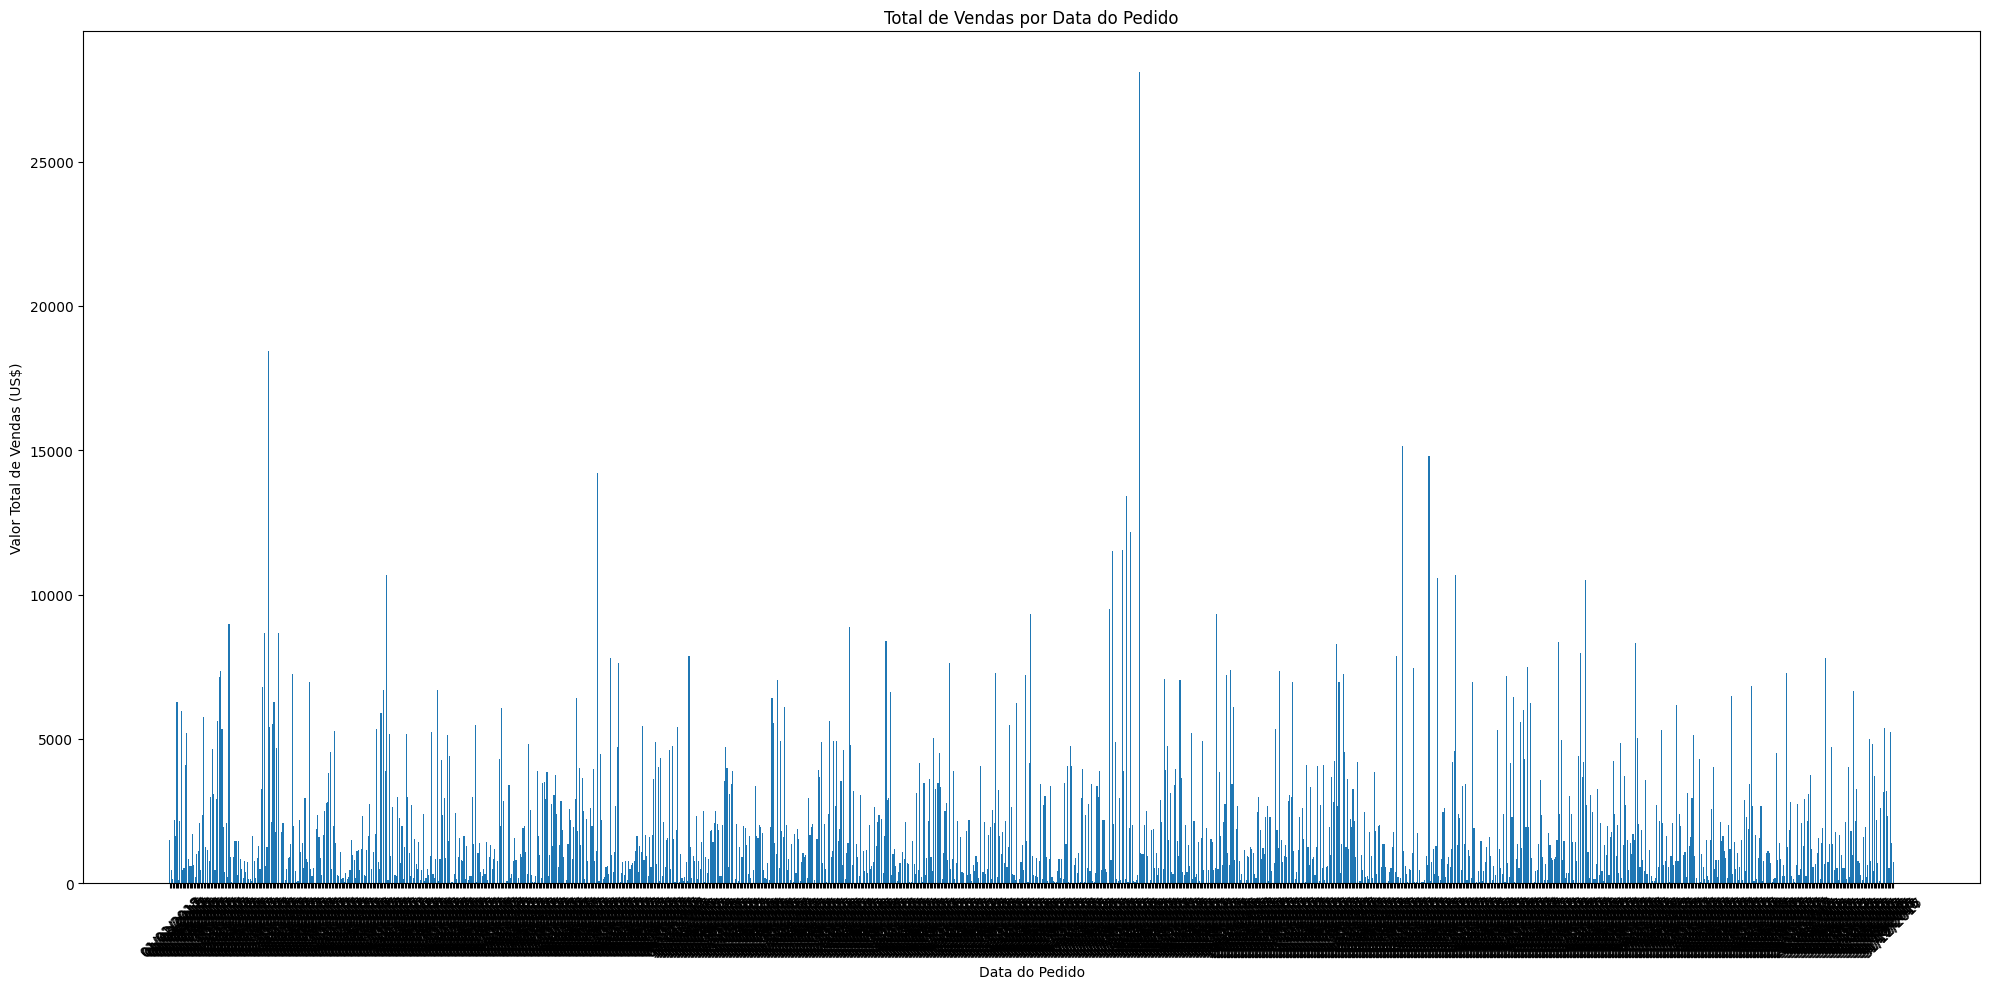

In [15]:
# Criando um gráfico de barras
plt.figure(figsize=(20, 10))
plt.bar(total_vendas_por_data_pedido['Data_Pedido'], total_vendas_por_data_pedido['Valor_Venda'])
plt.title('Total de Vendas por Data do Pedido')
plt.xlabel('Data do Pedido')
plt.ylabel('Valor Total de Vendas (US$)')
plt.xticks(rotation=45)  # Rotaciona as datas para melhor visualização
plt.tight_layout()  # Ajusta o layout para evitar cortes
plt.show()

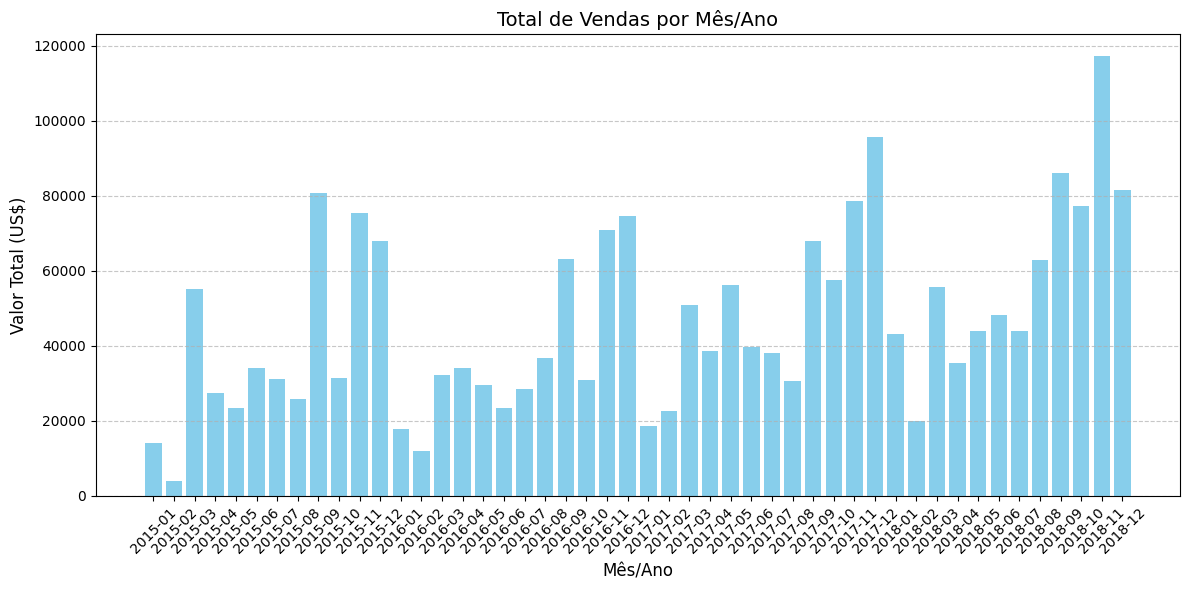

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Converter para datetime e extrair mês/ano
df_dsa['Data_Pedido'] = pd.to_datetime(df_dsa['Data_Pedido'], format='%d/%m/%Y')
df_dsa['Mes_Ano'] = df_dsa['Data_Pedido'].dt.to_period('M')

# Agrupar por mês/ano
vendas_mensais = df_dsa.groupby('Mes_Ano')['Valor_Venda'].sum().reset_index()
vendas_mensais['Mes_Ano'] = vendas_mensais['Mes_Ano'].astype(str)

# Plotar
plt.figure(figsize=(12, 6))
plt.bar(vendas_mensais['Mes_Ano'], vendas_mensais['Valor_Venda'], color='skyblue')
plt.title('Total de Vendas por Mês/Ano', fontsize=14)
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Valor Total (US$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Pergunta de Negócio 3:

### Qual o Total de Vendas por Estado?

Demonstre o resultado através de um gráfico de barras.

In [17]:
total_vendas_estado = df_dsa.groupby('Estado')['Valor_Venda'].sum().reset_index()
total_vendas_estado.head()

,Estado,Valor_Venda
0,Alabama,19510.6400
1,Arizona,35272.6570
2,Arkansas,11673.8300
3,California,442927.0975
4,Colorado,31841.5980


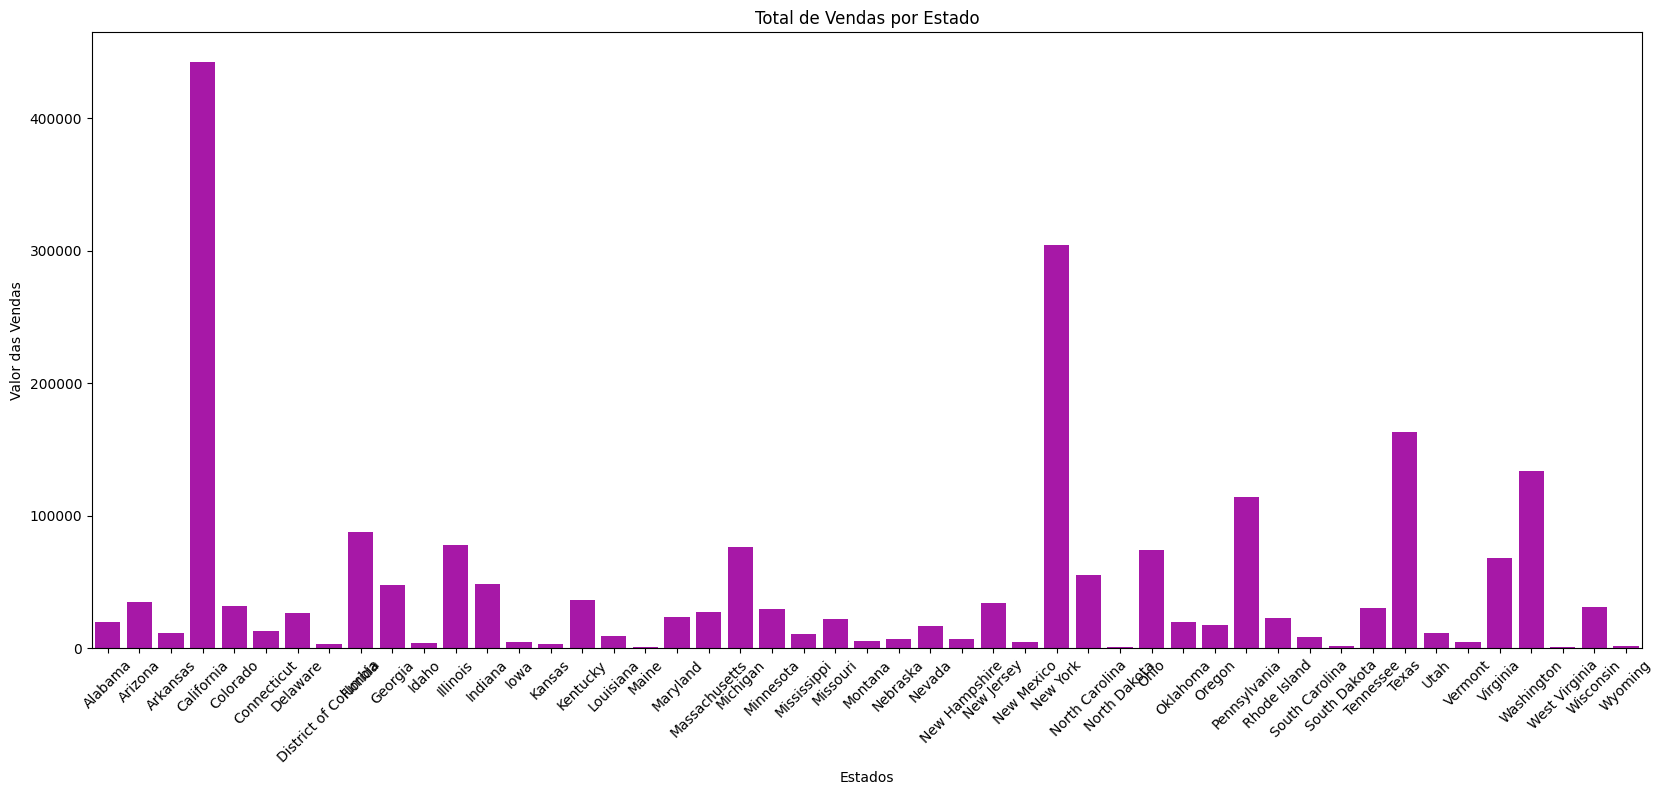

In [18]:
plt.figure(figsize=(20,8))
sns.barplot(data= total_vendas_estado, x= 'Estado', y= 'Valor_Venda', color='m')
plt.title('Total de Vendas por Estado')
plt.xlabel('Estados')
plt.ylabel('Valor das Vendas')
plt.xticks(rotation=45)
plt.show()

## Pergunta de Negócio 4:

### Quais São as 10 Cidades com Maior Total de Vendas?

Demonstre o resultado através de um gráfico de barras.

In [19]:
cidades_maior_total_vendas = df_dsa.groupby('Cidade')['Valor_Venda'].sum().reset_index()

In [20]:
top10_cidades_vendas = cidades_maior_total_vendas.sort_values('Valor_Venda', ascending=False).head(10)
top10_cidades_vendas

,Cidade,Valor_Venda
327,New York City,251749.2190
265,Los Angeles,171654.6330
450,Seattle,114725.4780
436,San Francisco,107489.9520
372,Philadelphia,107197.8030
207,Houston,61590.1868
435,San Diego,47458.3790
80,Chicago,46974.3430
216,Jacksonville,44713.1830
123,Detroit,42446.9440


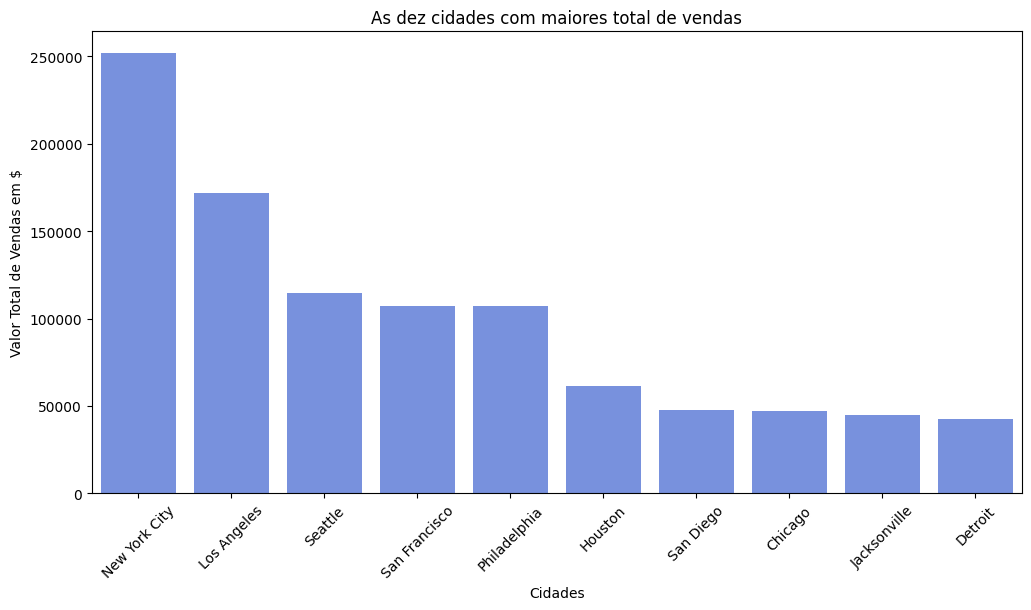

In [21]:
plt.figure(figsize=(12,6))
sns.set_palette('coolwarm')
sns.barplot(data= top10_cidades_vendas, x= 'Cidade', y='Valor_Venda')
plt.title('As dez cidades com maiores total de vendas')
plt.xlabel('Cidades')
plt.ylabel('Valor Total de Vendas em $')
plt.xticks(rotation=45)
plt.show()

## Pergunta de Negócio 5:

### Qual Segmento Teve o Maior Total de Vendas?

Demonstre o resultado através de um gráfico de pizza.

In [22]:
venda_segmento = df_dsa.groupby('Segmento')['Valor_Venda'].sum().reset_index()
# Configurar o pandas para mostrar todos os dígitos
pd.set_option('display.float_format', '{:.2f}'.format)

# Agora seu DataFrame mostrará os valores completos
print(venda_segmento)

      Segmento  Valor_Venda
0     Consumer   1133834.33
1    Corporate    679232.19
2  Home Office    422491.43


In [23]:
maior_venda_segmento = venda_segmento.sort_values('Valor_Venda', ascending=False).head()
maior_venda_segmento

,Segmento,Valor_Venda
0,Consumer,1133834.33
1,Corporate,679232.19
2,Home Office,422491.43


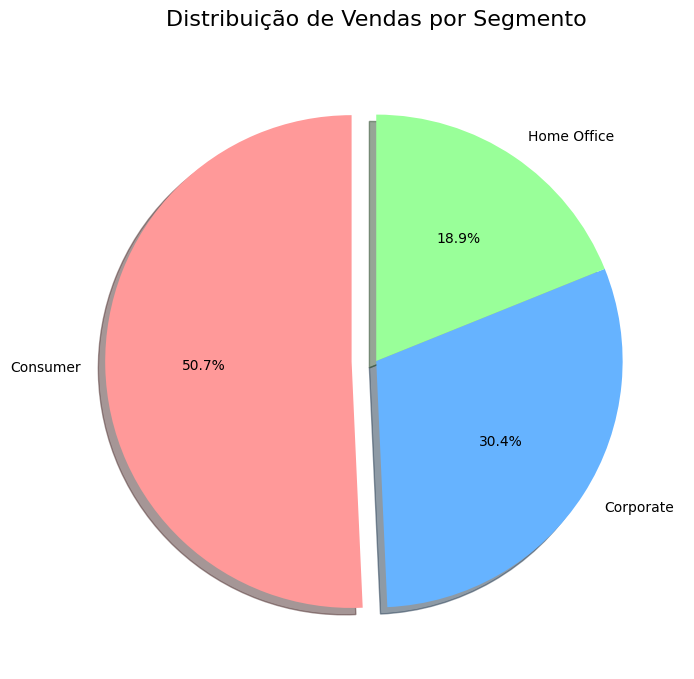


O segmento com maior total de vendas é: Consumer
Total de vendas: R$1,133,834.33


In [24]:
# Criar o gráfico de pizza
plt.figure(figsize=(8, 8))

# Parâmetros para destacar o maior segmento (explode)
explode = [0.1 if i == 0 else 0 for i in range(len(maior_venda_segmento))]

# Plotar o gráfico de pizza
plt.pie(maior_venda_segmento['Valor_Venda'], 
        labels=maior_venda_segmento['Segmento'],
        autopct='%1.1f%%',
        startangle=90,
        explode=explode,
        shadow=True,
        colors=['#ff9999','#66b3ff','#99ff99'])

# Adicionar título
plt.title('Distribuição de Vendas por Segmento', fontsize=16, pad=20)

# Mostrar o gráfico
plt.show()

# Exibir o segmento com maior venda separadamente
maior_segmento = maior_venda_segmento.iloc[0]
print(f"\nO segmento com maior total de vendas é: {maior_segmento['Segmento']}")
print(f"Total de vendas: R${maior_segmento['Valor_Venda']:,.2f}")

## Pergunta de Negócio 6 (Desafio Nível Baby):

### Qual o Total de Vendas Por Segmento e Por Ano?

In [25]:
# 1. Extrair o ano do ID_Pedido
df_dsa['Ano'] = df_dsa['ID_Pedido'].str.split('-').str[1].astype(int)

In [26]:
df_dsa.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Cidade,Estado,ID_Produto,Categoria,SubCategoria,Valor_Venda,Mes_Ano,Ano
0,CA-2017-152156,2017-11-08,CG-12520,Consumer,United States,Henderson,Kentucky,FUR-BO-10001798,Furniture,Bookcases,261.96,2017-11,2017
1,CA-2017-152156,2017-11-08,CG-12520,Consumer,United States,Henderson,Kentucky,FUR-CH-10000454,Furniture,Chairs,731.94,2017-11,2017
2,CA-2017-138688,2017-06-12,DV-13045,Corporate,United States,Los Angeles,California,OFF-LA-10000240,Office Supplies,Labels,14.62,2017-06,2017
3,US-2016-108966,2016-10-11,SO-20335,Consumer,United States,Fort Lauderdale,Florida,FUR-TA-10000577,Furniture,Tables,957.58,2016-10,2016
4,US-2016-108966,2016-10-11,SO-20335,Consumer,United States,Fort Lauderdale,Florida,OFF-ST-10000760,Office Supplies,Storage,22.37,2016-10,2016


In [27]:
vendas_segmento_ano = df_dsa.groupby(['Segmento', 'Ano'])['Valor_Venda'].sum().reset_index()


In [28]:
# Formatar a tabela de resultados
resultado_formatado = vendas_segmento_ano.copy()
resultado_formatado['Valor_Venda'] = resultado_formatado['Valor_Venda'].apply(lambda x: f'R${x:,.2f}')

print("Total de Vendas por Segmento e Ano:")
display(resultado_formatado)

Total de Vendas por Segmento e Ano:


,Segmento,Ano,Valor_Venda
0,Consumer,2015,"R$256,719.92"
1,Consumer,2016,"R$265,295.26"
2,Consumer,2017,"R$288,459.56"
3,Consumer,2018,"R$323,359.60"
4,Corporate,2015,"R$125,819.60"
5,Corporate,2016,"R$114,643.12"
6,Corporate,2017,"R$203,266.74"
7,Corporate,2018,"R$235,502.73"
8,Home Office,2015,"R$88,229.09"
9,Home Office,2016,"R$74,134.13"


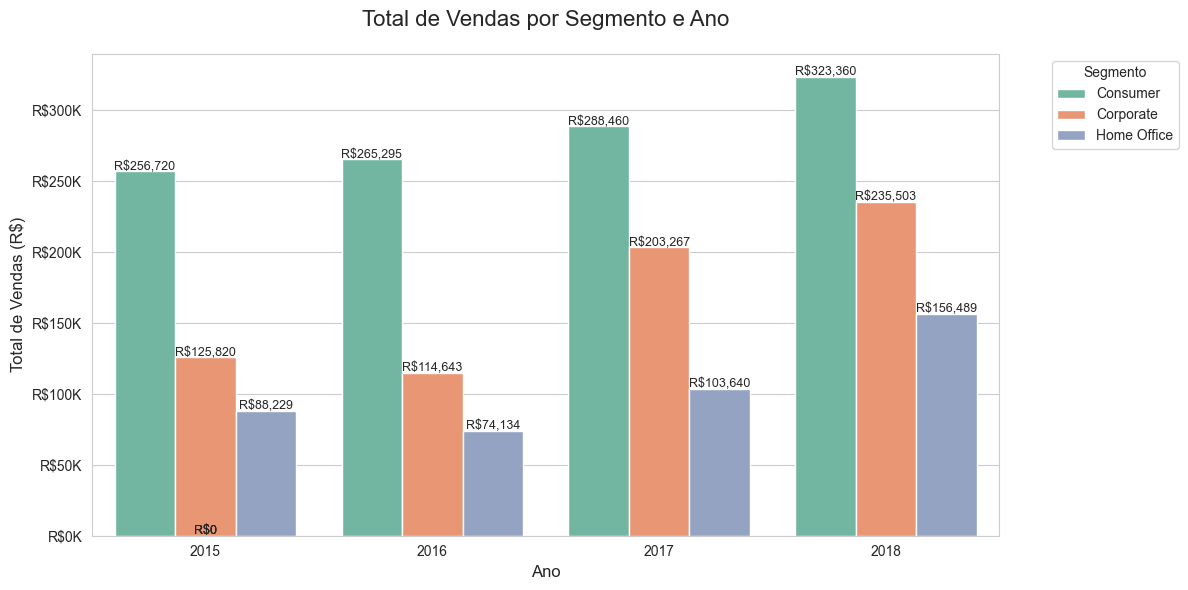


Variação Percentual Anual por Segmento:


,Segmento,Ano,Valor_Venda
0,Consumer,2015,"R$256,719.92"
1,Consumer,2016,"R$265,295.26"
2,Consumer,2017,"R$288,459.56"
3,Consumer,2018,"R$323,359.60"
4,Corporate,2015,"R$125,819.60"
5,Corporate,2016,"R$114,643.12"
6,Corporate,2017,"R$203,266.74"
7,Corporate,2018,"R$235,502.73"
8,Home Office,2015,"R$88,229.09"
9,Home Office,2016,"R$74,134.13"


In [29]:
# Criar visualização gráfica
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Gráfico de barras agrupadas
ax = sns.barplot(data=vendas_segmento_ano, 
                 x='Ano', 
                 y='Valor_Venda', 
                 hue='Segmento',
                 palette='Set2')

# Configurações do gráfico
plt.title('Total de Vendas por Segmento e Ano', fontsize=16, pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Total de Vendas (R$)', fontsize=12)

# Formatar eixos
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R${x/1000:,.0f}K"))

# Adicionar valores nas barras
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1000,
            f'R${height:,.0f}',
            ha="center", 
            fontsize=9)

plt.legend(title='Segmento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Análise adicional - Variação percentual anual por segmento
with pd.option_context('display.float_format', 'R${:,.2f}'.format):
    print("\nVariação Percentual Anual por Segmento:")
    display(vendas_segmento_ano)

## Pergunta de Negócio 7 (Desafio Nível Júnior):

Os gestores da empresa estão considerando conceder diferentes faixas de descontos e gostariam de fazer uma simulação com base na regra abaixo:

- Se o Valor_Venda for maior que 1000 recebe 15% de desconto.
- Se o Valor_Venda for menor que 1000 recebe 10% de desconto.

### Quantas Vendas Receberiam 15% de Desconto?

In [30]:
# 1. Criar a coluna de faixa de desconto
df_dsa['Faixa_Desconto'] = pd.cut(df_dsa['Valor_Venda'],
                                 bins=[0, 1000, float('inf')],
                                 labels=['10%', '15%'])

# 2. Contar quantas vendas receberiam cada desconto
contagem_descontos = df_dsa['Faixa_Desconto'].value_counts().sort_index()

# 3. Obter especificamente as vendas com 15% de desconto
vendas_15porcento = contagem_descontos.get('15%', 0)

# 4. Mostrar os resultados
print(f"Total de vendas que receberiam 15% de desconto: {vendas_15porcento}")
print("\nDistribuição completa de descontos:")
print(contagem_descontos)

Total de vendas que receberiam 15% de desconto: 457

Distribuição completa de descontos:
10%    9243
15%     457
Name: Faixa_Desconto, dtype: int64


In [31]:
# Remover o símbolo % e converter para float, depois dividir por 100
df_dsa['Faixa_Desconto'] = df_dsa['Faixa_Desconto'].str.replace('%', '').astype(float) / 100

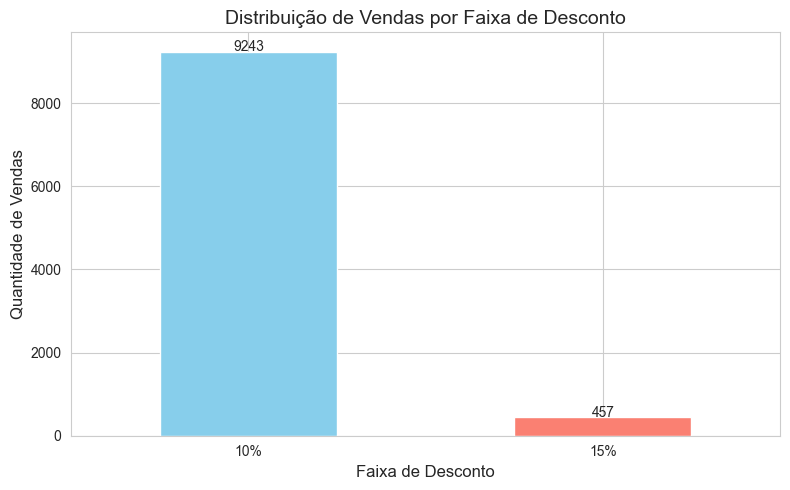

In [32]:
# Criando um gráfico demonstrativo
plt.figure(figsize=(8, 5))
contagem_descontos.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribuição de Vendas por Faixa de Desconto', fontsize=14)
plt.xlabel('Faixa de Desconto', fontsize=12)
plt.ylabel('Quantidade de Vendas', fontsize=12)
plt.xticks(rotation=0)

# Adicionar os valores nas barras
for i, valor in enumerate(contagem_descontos):
    plt.text(i, valor + 5, str(valor), ha='center')

plt.tight_layout()
plt.show()

## Pergunta de Negócio 8 (Desafio Nível Master):

### Considere Que a Empresa Decida Conceder o Desconto de 15% do Item Anterior. Qual Seria a Média do Valor de Venda Antes e Depois do Desconto?

In [33]:
# Criando uma coluna calculando o valor da venda menos o desconto
df_dsa['Valor_Venda_Desconto'] = df_dsa['Valor_Venda'] - (df_dsa['Valor_Venda'] * df_dsa['Faixa_Desconto'])

In [34]:
# Filtrando as vendas antes do desconto de 15%
df_dsa_venda_antes_desconto = df_dsa.loc[df_dsa['Faixa_Desconto'] == 0.15, 'Valor_Venda']

In [35]:
# Filtrando as vendas depois do desconto de 15%
df_dsa_venda_depois_desconto = df_dsa.loc[df_dsa['Faixa_Desconto'] == 0.15, 'Valor_Venda_Desconto']

In [36]:
# Calcular a media das vendas antes do desconto
media_venda_antes_desconto = df_dsa_venda_antes_desconto.mean()

In [37]:
# Calcular a media das vendas depois do desconto
media_venda_depois_desconto = df_dsa_venda_depois_desconto.mean()

In [38]:
# Visualizando o resultado
print("Média das vendas antes do desconto de 15%:", round(media_venda_antes_desconto, 2))

Média das vendas antes do desconto de 15%: 2116.81


In [39]:
# Visualizando o resultado
print("Média das vendas depois do desconto de 15%:", round(media_venda_depois_desconto, 2))

Média das vendas depois do desconto de 15%: 1799.29


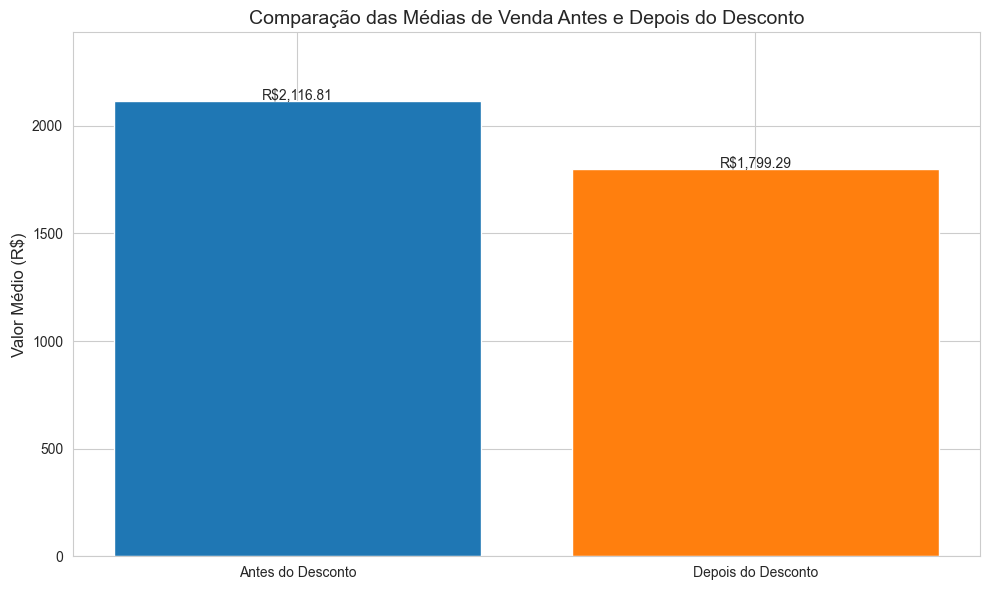

In [40]:
# 5. Visualização gráfica
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Gráfico de barras para as médias
medias = [media_venda_antes_desconto, media_venda_depois_desconto]
rotulos = ['Antes do Desconto', 'Depois do Desconto']
cores = ['#1f77b4', '#ff7f0e']

plt.bar(rotulos, medias, color=cores)

# Adicionar os valores nas barras
for i, valor in enumerate(medias):
    plt.text(i, valor + 5, f'R${valor:,.2f}', ha='center')

plt.title('Comparação das Médias de Venda Antes e Depois do Desconto', fontsize=14)
plt.ylabel('Valor Médio (R$)', fontsize=12)
plt.ylim(0, max(medias) * 1.15)

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

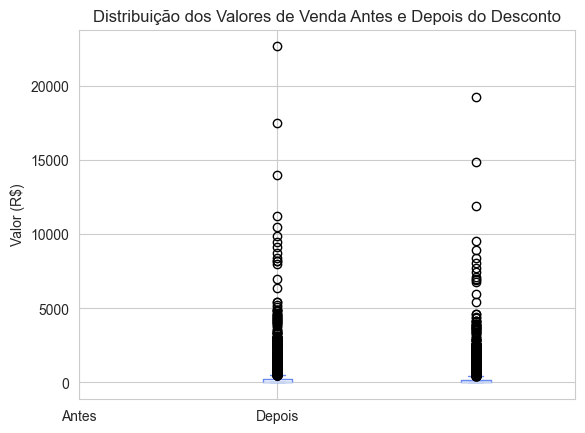

In [41]:
# Boxplot comparativo
plt.figure(figsize=(10, 6))
df_dsa[['Valor_Venda', 'Valor_Venda_Desconto']].plot(kind='box')
plt.title('Distribuição dos Valores de Venda Antes e Depois do Desconto')
plt.ylabel('Valor (R$)')
plt.xticks([0, 1], ['Antes', 'Depois'])
plt.show()

## Pergunta de Negócio 9 (Desafio Nível Master Ninja):

### Qual o Média de Vendas Por Segmento, Por Ano e Por Mês?

Demonstre o resultado através de gráfico de linha.

In [42]:
# Extraindo o mês e gravando em uma nova variável
df_dsa['Mes'] = df_dsa['Data_Pedido'].dt.month

In [43]:
# Agrupamos por Ano, Mes e Segmento e agrupamos por estatísticas de agregação
df_dsa_Media_Seg_Ano_Mes = df_dsa.groupby(['Ano', 'Mes', 'Segmento'])['Valor_Venda'].agg([np.sum, np.mean, np.median])

In [44]:
df_dsa_Media_Seg_Ano_Mes.head()

sum   mean  median
Ano  Mes Segmento                          
2015 1   Consumer    6896.63 146.74   36.44
         Corporate   1701.53 130.89   51.94
         Home Office 5607.55 329.86   62.82
     2   Consumer    3167.85 117.33   22.78
         Corporate    623.12  69.24   62.31

In [45]:
# Vamos extrair os níveis
anos = df_dsa_Media_Seg_Ano_Mes.index.get_level_values(0)
meses = df_dsa_Media_Seg_Ano_Mes.index.get_level_values(1)
segmentos = df_dsa_Media_Seg_Ano_Mes.index.get_level_values(2)

<Figure size 1200x600 with 0 Axes>

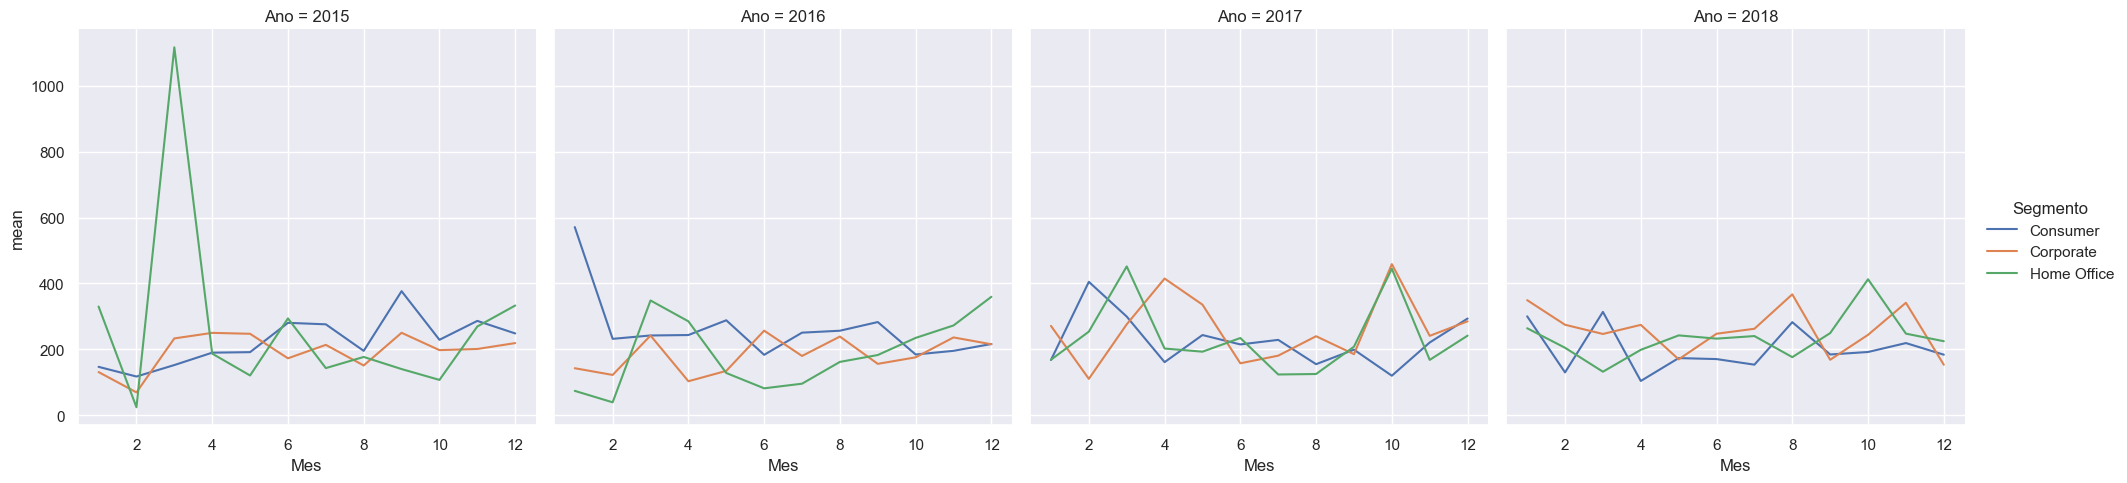

In [46]:
# Gráfico de linhas
plt.figure(figsize = (12,6))
sns.set()
fig1 = sns.relplot(kind = 'line',
                   data = df_dsa_Media_Seg_Ano_Mes,
                   y = 'mean',
                   x = meses,
                   hue = segmentos,
                   col = anos,
                   col_wrap = 4)
plt.show()

In [47]:
df_dsa.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Cidade,Estado,ID_Produto,Categoria,SubCategoria,Valor_Venda,Mes_Ano,Ano,Faixa_Desconto,Valor_Venda_Desconto,Mes
0,CA-2017-152156,2017-11-08,CG-12520,Consumer,United States,Henderson,Kentucky,FUR-BO-10001798,Furniture,Bookcases,261.96,2017-11,2017,0.10,235.76,11
1,CA-2017-152156,2017-11-08,CG-12520,Consumer,United States,Henderson,Kentucky,FUR-CH-10000454,Furniture,Chairs,731.94,2017-11,2017,0.10,658.75,11
2,CA-2017-138688,2017-06-12,DV-13045,Corporate,United States,Los Angeles,California,OFF-LA-10000240,Office Supplies,Labels,14.62,2017-06,2017,0.10,13.16,6
3,US-2016-108966,2016-10-11,SO-20335,Consumer,United States,Fort Lauderdale,Florida,FUR-TA-10000577,Furniture,Tables,957.58,2016-10,2016,0.10,861.82,10
4,US-2016-108966,2016-10-11,SO-20335,Consumer,United States,Fort Lauderdale,Florida,OFF-ST-10000760,Office Supplies,Storage,22.37,2016-10,2016,0.10,20.13,10


## Pergunta de Negócio 10 (Desafio Nível Master Ninja das Galáxias):

### Qual o Total de Vendas Por Categoria e SubCategoria, Considerando Somente as Top 12 SubCategorias? 

Demonstre tudo através de um único gráfico.

In [48]:
# Agrupamos por categoria e subcategoria e calculamos a soma somente para variáveis numéricas
vendas_subcat = df_dsa.groupby(['Categoria',
                                'SubCategoria']).sum(numeric_only = True).sort_values('Valor_Venda', ascending=False).head(12)

In [49]:
# Convertemos a coluna Valor_Venda em número inteiro e classificamos por categoria
vendas_subcat = vendas_subcat[['Valor_Venda']].astype(int).sort_values(by='Categoria').reset_index()

In [50]:
vendas_subcat.head(12)

,Categoria,SubCategoria,Valor_Venda
0,Furniture,Chairs,317919
1,Furniture,Tables,202083
2,Furniture,Bookcases,108045
3,Furniture,Furnishings,88862
4,Office Supplies,Storage,216188
5,Office Supplies,Binders,194723
6,Office Supplies,Appliances,104061
7,Office Supplies,Paper,76312
8,Technology,Phones,325271
9,Technology,Machines,189238


In [51]:
# Criando outro DataFrame somente com os totais por categoria
vendas_categ = df_dsa.groupby('Categoria').sum(numeric_only= True).reset_index()

In [52]:
vendas_categ.head()

,Categoria,Valor_Venda,Ano,Faixa_Desconto,Valor_Venda_Desconto,Mes
0,Furniture,716910.80,4144358,213.70,631485.62,16307
1,Office Supplies,695097.77,11799862,590.95,613400.49,45575
2,Technology,823549.38,3618020,188.20,718746.99,14044


In [53]:
# Listagem de cores para categoria
cores_categorias = ['#5d00de',
                    '#0ee84f',
                    '#e80e27',]

In [54]:
# Listagem de cores para subcategorias
cores_subcategorias = ['#aa8cd4',
                       '#aa8cd5',
                       '#aa8cd6',
                       '#aa8cd7',
                       '#26c957',
                       '#26c958',
                       '#26c959',
                       '#26c960',
                       '#e65e65',
                       '#e65e66',
                       '#e65e67',
                       '#e65e68']

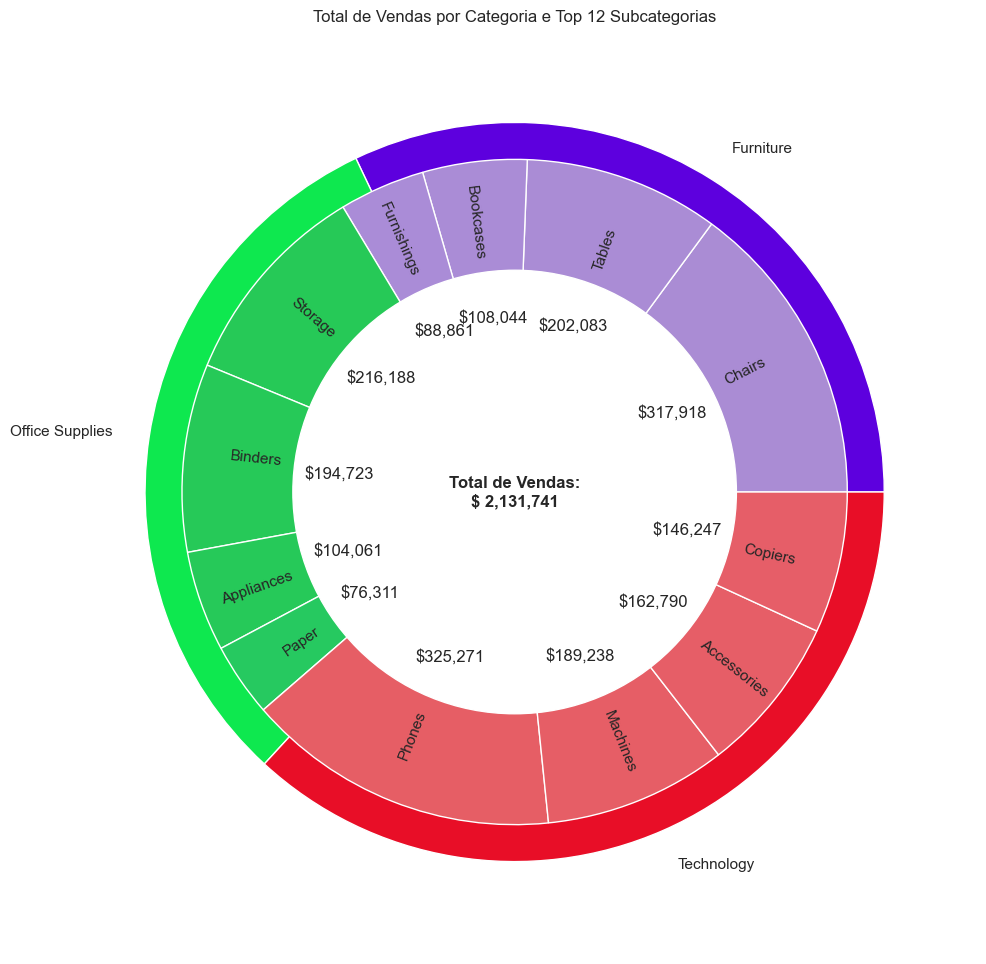

In [57]:
# Plotando dois gráficos

# Gráfico 01
# Tamanho da figura
fig, ax = plt.subplots(figsize=(18,12))

# Gráfico das categorias
p1 = ax.pie(vendas_categ['Valor_Venda'],
    radius = 1,
    labels = vendas_categ['Categoria'], 
    wedgeprops = dict(edgecolor = 'white'), 
    colors = cores_categorias)

# Gráfico das subcategorias
total_subcat = sum(vendas_subcat['Valor_Venda'])
p2 = ax.pie(vendas_subcat['Valor_Venda'],
    radius = 0.9,
    labels = vendas_subcat['SubCategoria'], 
    autopct = lambda pct: f'${int(pct * total_subcat / 100):,}',
    colors = cores_subcategorias, 
    labeldistance = 0.7, 
    wedgeprops = dict(edgecolor='white'),
    pctdistance = 0.53,
    rotatelabels = True)

# Limpa o centre do círculo
centre_circle = plt.Circle((0, 0), 0.6, fc = 'white')

# Labels e anotações
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Anotação com o total de vendas (melhor posicionada)
total_vendas = sum(vendas_subcat['Valor_Venda'])
plt.annotate(text = f'Total de Vendas:\n$ {total_vendas:,}', 
             xy = (0, 0), 
             ha='center', 
             va='center', 
             fontsize=12, 
             fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.title('Total de Vendas por Categoria e Top 12 Subcategorias')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker  # Importação específica para formatação

# 1. PREPARAÇÃO DOS DADOS
try:
    top12 = (df_dsa.groupby(['Categoria', 'SubCategoria'])
             ['Valor_Venda'].sum()
             .nlargest(12)
             .reset_index()
             .sort_values('Valor_Venda'))
except Exception as e:
    print(f"Erro ao preparar dados: {e}")
    raise

# 2. CONFIGURAÇÃO DO GRÁFICO
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 7))

# 3. CORES E ESTILO
cores = {
    'Furniture': '#3574D2',
    'Office Supplies': '#FF7F0E', 
    'Technology': '#2CA02C'
}
max_width = top12['Valor_Venda'].max()

# 4. PLOTAGEM PRINCIPAL
bars = ax.barh(
    top12['SubCategoria'],
    top12['Valor_Venda'],
    color=[cores[c] for c in top12['Categoria']],
    height=0.7
)

# 5. FORMATAÇÃO DO EIXO X (VERSÃO À PROVA DE ERROS)
try:
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'R${x/1000:,.0f}K')  # Formato correto
    )
except NameError:
    # Fallback se houver erro com ticker
    ax.set_xticklabels([f'R${x/1000:,.0f}K' for x in ax.get_xticks()])

ax.set_xlim(0, max_width * 1.18)

# 6. AJUSTE DE POSICIONAMENTO DOS VALORES
for bar in bars:
    width = bar.get_width()
    ax.text(
        width * 0.97,  # 3% antes do final da barra
        bar.get_y() + bar.get_height()/2,
        f'R${width:,.0f}',
        va='center',
        ha='right',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

# 7. ELEMENTOS ADICIONAIS
ax.set_title('TOP 12 SUBCATEGORIAS POR VENDAS', pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel('Total de Vendas (milhares de R$)', labelpad=12)
ax.grid(axis='x', alpha=0.3)

# 8. LEGENDA
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cores[k], label=k) for k in cores]
ax.legend(handles=legend_elements, title='Categoria', loc='lower right')

plt.tight_layout()
plt.show()

# Fim